## Adding Features

In [1]:
import numpy as np
import pandas as pd
from darts import TimeSeries
from darts.models import ARIMA
import matplotlib.pyplot as plt
from tqdm import tqdm
import time
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report

In [2]:
data = pd.read_csv('data_cleaned.csv')
data['date']= pd.to_datetime(data['Unnamed: 0'])
#data.set_index('Unnamed: 0', inplace=True)

In [3]:
train = data[data['date']<'2014-01-01']
test = data[data['date']>='2014-01-01']

#train = TimeSeries.from_dataframe(train, value_cols='unit_sales')
#test = TimeSeries.from_dataframe(test, value_cols='unit_sales')

In [4]:
# Lag features (per store and item)
train['lag_1'] = train['unit_sales'].shift(1)
train['lag_7'] = train['unit_sales'].shift(7)
train['lag_30'] = train['unit_sales'].shift(30)

# Rolling statistics
train['rollings_avg_3'] = train["unit_sales"].rolling(window=3).mean().shift(1)

In [7]:
#hinzufügen: wochentag, is weekend, holidays, oil
train['day_of_week'] = train['date'].dt.dayofweek
train['is_weekend'] = train['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)

#import holidays
holidays=pd.read_csv('holidays_cleaned.csv')
holidays['date']= pd.to_datetime(holidays['date'])
#holidays.drop('Unnamed: 0', axis=1, inplace=True)
#holidays.set_index('Unnamed: 0', inplace=True)

In [8]:
#if there's a holiday on that day/ that day in the list of holidays, the value is 1
train['is_holiday']=train['date'].apply(lambda x: 1 if x in set(holidays['date']) else 0)

In [9]:
oil=pd.read_csv('oil_cleaned.csv')
oil['date']= pd.to_datetime(oil['Unnamed: 0'])

In [31]:
oil.head()

,Unnamed: 0,dcoilwtico,date
0,2013-01-01,NaN,2013-01-01
1,2013-01-02,93.14,2013-01-02
2,2013-01-03,92.97,2013-01-03
3,2013-01-04,93.12,2013-01-04
4,2013-01-05,93.12,2013-01-05


In [10]:
oil.drop('Unnamed: 0', axis=1, inplace=True)
train=pd.merge(train,oil, on='date', how='left')
# join, to be sure, that the dates and Oil price is right.
# left: because train is the important one, I need all of it and nothing more.

In [11]:
train.drop('Unnamed: 0', axis=1, inplace=True) #dunno how that got there
#train.dropna() #no Nan values # xgboost is okay with nan values, so I don't have to

## XGBoost

In [12]:
# defining y and x
y_train = train['unit_sales']
x_train = train.drop('unit_sales', axis=1)
x_train= x_train.drop('date', axis=1)

y_test = test.drop('date', axis=1)

In [18]:
# Initialize the XGBoost regressor
model_xgboost = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1
)

# Train the XGBoost model
model_xgboost.fit(x_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [16]:
train

,unit_sales,date,lag_1,lag_7,lag_30,rollings_avg_3,day_of_week,is_weekend,is_holiday,dcoilwtico
0,582.0,2013-01-02,NaN,NaN,NaN,NaN,2,0,0,93.14
1,310.0,2013-01-03,582.0,NaN,NaN,NaN,3,0,0,92.97
2,338.0,2013-01-04,310.0,NaN,NaN,NaN,4,0,0,93.12
3,654.0,2013-01-05,338.0,NaN,NaN,410.000000,5,1,1,93.12
4,979.0,2013-01-06,654.0,NaN,NaN,434.000000,6,1,0,93.12
...,...,...,...,...,...,...,...,...,...,...
359,419.0,2013-12-27,418.0,441.0,474.0,382.666667,4,0,0,99.94
360,499.0,2013-12-28,419.0,630.0,258.0,400.666667,5,1,0,99.94
361,552.0,2013-12-29,499.0,985.0,363.0,445.333333,6,1,0,99.94
362,595.0,2013-12-30,552.0,523.0,726.0,490.000000,0,0,0,98.90


In [17]:
#creating the columns for y iterative
'''
train_df = train.set_index("date")      #creating a new df to write into
history = train_df["unit_sales"].copy() #y values in history
forecasts = []                          #empty list for the forecast
last_date = history.index[-1]           #date of lag 1
next_date = last_date + pd.Timedelta(days=1)    #next date to forecast
'''

In [38]:
def iterative_forecast(model, train_df, n_future_days):
    train_df = train_df.set_index("date")
    # Work on a copy so we don't mutate the original
    history = train_df["unit_sales"].copy()

    forecasts = []
    last_date = history.index[-1]

    for i in range(1, n_future_days + 1):
        next_date = last_date + pd.Timedelta(days=i)

        #
        # --- Lag features ---
        lag_1  = history.iloc[-1]
        lag_7  = history.iloc[-7]  if len(history) >= 7  else history.iloc[0]
        lag_30 = history.iloc[-30] if len(history) >= 30 else history.iloc[0]

        # --- Rolling average (last 2 values) ---
        rolling_avg_3 = history.iloc[-3:].mean()

        # --- Calendar features ---
        day_of_week = next_date.dayofweek          # 0 = Monday … 6 = Sunday
        is_weekend  = int(day_of_week >= 5)
        if next_date in set(holidays['date']):
            is_holiday= 1
        else:
            is_holiday = 0
        dcoilwtico  = oil[oil['date']==next_date]['dcoilwtico'].values[0]


        # --- Build the feature row (column order must match training) ---
        row = pd.DataFrame({
            "lag_1":          [lag_1],
            "lag_7":          [lag_7],
            "lag_30":         [lag_30],
            "rollings_avg_3": [rolling_avg_3],
            "day_of_week":    [day_of_week],
            "is_weekend":     [is_weekend],
            'is_holiday':     [is_holiday],
            "dcoilwtico":     [dcoilwtico]
        })

        #
        # --- Predict and store ---
        yhat = model_xgboost.predict(row)[0]
        forecasts.append({"date": next_date, "unit_sales": yhat})

        # --- Append prediction to history so next iteration can use it ---
        history.loc[next_date] = yhat

    return pd.DataFrame(forecasts)

In [40]:
forecast_xgboost = iterative_forecast(model_xgboost, train, len(y_test))

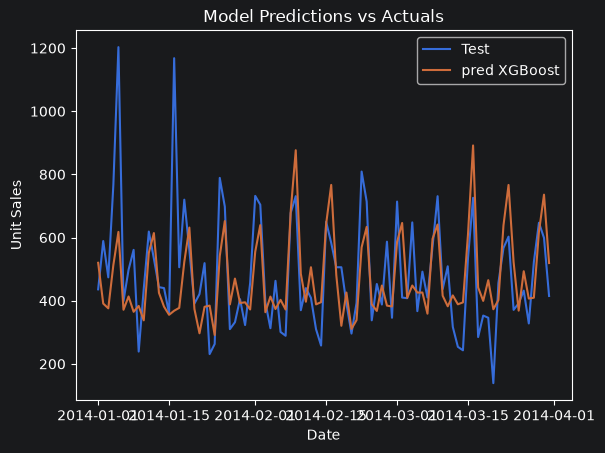

In [46]:
plt.plot(test['date'], test['unit_sales'], label='Test')
plt.plot(forecast_xgboost['date'], forecast_xgboost['unit_sales'], label='pred XGBoost')
plt.legend()
plt.title('Model Predictions vs Actuals')
plt.xlabel('Date')
plt.ylabel('Unit Sales')
plt.show()

In [ ]:
'''
model_evaluation=pd.DataFrame(columns=['model','aic','mae','mse','r2'])

aic=model_arima.model.aic
mae=mean_absolute_error(test_val,forecast_arima.values().flatten())
mse=mean_squared_error(test_val,forecast_arima.values().flatten())
r2= r2_score(test_val,forecast_arima.values().flatten())

#new entry for arima at the End of the DF (len()) with the metrics
model_evaluation.loc[len(model_evaluation)] = ['arima', aic, mae, mse, r2]
'''

## Model 2

## Model 3